# Exploring data separation: global graph state, LLM node input- and output states

Data Minimization, Privacy by Design, is key when working with LLMs:

 - private data should never cross system boundaries, especially not towards untrusted systems
 - LLMs may be hosted externally, and thereby mark a system boundary
 - LLMs are non-deterministic, and they may or may not trigger safe actions
 

 After creating a tool to inspect messages from LLMs in the last notebook (`src/assorted/session3/langgraph_messages.ipynb`) this notebook is about exploring how to prevent LLM nodes access to private data, how to implement data minimization.

 To keep the notebook comprehensive code was refactored and moved under the src/ directory. Key files to look at are:

 - `src/llm_nodes/global_state.py` - graph global state (data)
 - `src/llm_nodes/todo_*/graph.py` - subgraph bridge implementing data minimalism
 - `src/llm_nodes/todo_*/nodes.py` - LLM node implementation

 Once more, this notebook does not build a fully functional agent. This is yet another building block on the way exploring privacy by design on the way to an agent dealing with PII. The agents task is as "simple" as extracting a TODO list from a given text that contains emails (as one example of PII) while ensuring emails are kept private. The objective here is not a perfectly working agent, it is laying out the fundamental infrastructure. 

In [1]:
import sys

# See README.md - only valid for devcontainer workflow!
sys.path.insert(0, "/workspace")

from typing import Callable

from src.reducer.base_reader import BaseReducerReader

from langgraph.graph import END, START, StateGraph
from langchain_core.messages import HumanMessage
import logging

from IPython.display import Image, display
from src.llm_nodes.global_state import GlobalState
from src.logging_setup import get_logger
from src.reducer.reducer_session import reducer_session
from src.llm_nodes.pii_email.nodes import get_pii_email_node
from src.llm_nodes.pii_email.mask import demask_pii_emails
from src.llm_nodes.todo_extract.graph import build_todo_extract_subgraph, make_todo_extract_subgraph_runner
from src.llm_nodes.todo_markdown.graph import build_todo_markdown_subgraph, make_todo_markdown_subgraph_runner


## Setup input, model, logger ...

In [2]:
MODEL = "ollama_chat/llama3.2:3b"
# MODEL = "groq/llama-3.3-70b-versatile"

pii_email = """
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.
"""

logger = get_logger(__name__, "assorted/session4/langgraph.ipynb")
logger.setLevel(logging.INFO)

## Towards securing the data flow

A common way to exchange data between nodes in a langgraph graph is using the graph state. In case of this example agent the global state carries information that does not need to, that should not and must not propagate to all the nodes. Building a TODO list does not require access to PII, here email address. 

The graph global state (`src/llm_nodes/global_state.py`) holds such information:

```python
class GlobalState(BaseState):
    
    messages: Annotated[list[BaseMessage], session_message_reducer] = Field(default_factory=list)
    pii_email: PIIEmail = Field(default_factory=PIIEmail)
    ... 
```

The raw text to be processed is part of `messages` and the node extracting emails populates `pii_email` which holds the raw emails and placeholder for each one:

`ulf.wendel@phpdoc.de` -> `EMAIL0` 

A node building a TODO list can carry out its task perfectly when only given the placeholder:

`TODO.who`: `EMAIL0`

Therefore, the TODO list node should not gain access to all of `GlobalState` including raw emails. Instead, the TODO list node operates on `pii_email.text` which contains the placeholder. 

### StateGraph.add_node(..., input_schema: type[NodeInputT] | None = None, ... )

Upon compilation of the state graph, when adding a node, Langgraph allows setting an input filter for the state passed to the node via `input_schema`. It can be used to 
sieve out keys from the global state that shall be invisible to the node. When using Pydantic BaseModel you can also transform the contents of those keys passed to the node using validators:

`GlobalState` -> filter in accordance with -> `input_schema` 

In other words:

Parent node/graph -> READ filter on `GlobalState` --> Child node/graph

But using `input_schema` does not protect against a malicious or erroneous node writing back to the global state:

Child node/graph --> WRITE to `GlobalState` -> Parent node/graph

The goal here is stronger protection than what `input_schema` allows. 

### Subgraph bridge

Stricter data isolation can be achieved using a subgraph bridge. The untrusted LLM node runs in its own subgraph, thus having its own state. A bridge function extracts information from the global state to build the subgraph input state:

Parent node/graph -> bridge invokes compiled subgraph -> bridge maps `GlobalState` to subgraph input-> child node

The bridge also handles copying the reply from the untrusted LLM node back to the global state:

child node -> subgraph state -> bridge mapping to `GlobalState` -> Parent node/graph

In [3]:
# Isolated subgraph (TODOState) + bridge node for the parent graph
todo_extract_graph = build_todo_extract_subgraph(MODEL)
run_todo_extract_graph = make_todo_extract_subgraph_runner(todo_extract_graph)

todo_markdown_graph = build_todo_markdown_subgraph(MODEL)
run_todo_markdown_graph = make_todo_markdown_subgraph_runner(todo_markdown_graph)


`build_todo_extract_subgraph` (`src/llm_nodes/todo_extract/graph.py`) builds and compiles a LangGraph (sub-)graph:

```python
def build_todo_extract_subgraph(model: str) -> CompiledStateGraph:
    """Compile an isolated graph on ``TODOState`` (no session/config at build time)."""
    builder = StateGraph(TODOState)
    builder.add_node("todo_extract", get_todo_list_node(model))
    builder.add_edge(START, "todo_extract")
    builder.add_edge("todo_extract", END)
    return builder.compile()
```

Note that the (sub-)graph works on `TODOState`, which is independent from `GlobalState`. PII from `GlobalState` is neither directly readable- nor writable by the (sub-)graph.  

`make_todo_extract_subgraph_runner` is a callable factory with closure over `CompiledStateGraph`:

```python
def make_todo_extract_subgraph_runner(todo_graph: CompiledStateGraph):
    
    async def run_todo_extract_subgraph(
        state: GlobalState,
        config: RunnableConfig,
    ) -> dict:
        ...

        sub_result = await todo_graph.ainvoke(
            {"text": state.pii_email.text},
            config=config,
        )

        return {
            "todo_list": TODOList.model_validate(sub_result["todo_list"]),
            "messages": sub_result.get("messages", []),
        }

    return run_todo_extract_subgraph
```
  
The factory returns a function with the signature expected by LangGraph: `run_todo_extract_subgraph(state: GlobalState, config: RunnableConfig)` . This function maps selected data from `GlobalState` to the (sub-)graphs `TODOState`. The actual LLM node, `get_todo_list_node()` (`src/llm_nodes/todo_extract/nodes.py`) is:

```python
class LlmNodeTODOList:
    
    async def __call__(self, state: TODOState) -> dict:
        ...
```

Even if this LLM node performs malicious or erroneous actions, it will not be able to read all of the `GlobalState` or write to it. The LLM node actions are constrained by the rules implemented in the bridge. In this particular example, the LLM node gets access to the text with email addresses replaced by placeholders only but the bridge does merge all LLM node messages into the `GlobalState`. In a production environment you might want to be stricter here. 

## Parent graph (GlobalState)

Building and compiling the global graph: `todo_list_node` is the bridge (`run_todo_extract_graph`), not the raw subgraph (`todo_extract_graph`).

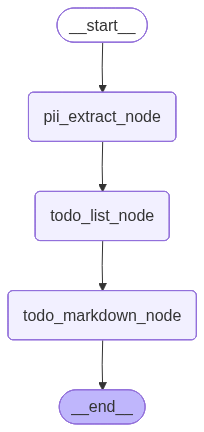

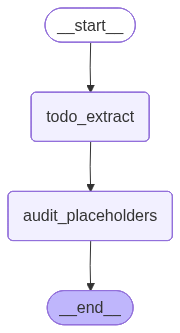

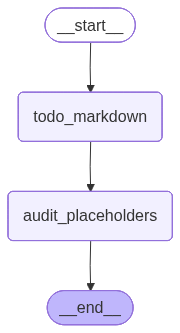

In [4]:
build_graph = StateGraph(GlobalState)

build_graph.add_node("pii_extract_node", get_pii_email_node(model=MODEL))
build_graph.add_node("todo_list_node", run_todo_extract_graph)
build_graph.add_node("todo_markdown_node", run_todo_markdown_graph)

build_graph.add_edge(START, "pii_extract_node")
build_graph.add_edge("pii_extract_node", "todo_list_node")
build_graph.add_edge("todo_list_node", "todo_markdown_node")
build_graph.add_edge("todo_markdown_node", END)

graph = build_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
display(Image(todo_extract_graph.get_graph().draw_mermaid_png()))
display(Image(todo_markdown_graph.get_graph().draw_mermaid_png()))

In [5]:
print("----")
print("")
print("Original text:")
print(pii_email)

----

Original text:

This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.



### Invoke

In [6]:
def make_reader(get_thread_id: Callable[[], str]):
    return BaseReducerReader(get_thread_id=get_thread_id)


reducer = None
with reducer_session("Chat-ABC", factory=make_reader) as session:

    reducer = session.reducer

    state = session.state(GlobalState, [HumanMessage(content=pii_email)])
    reply = await session.ainvoke(graph, state)

    state = GlobalState.model_validate(reply)
    logging.debug("Observed, raw messages with content:")
    for m in state.messages:
        if hasattr(m, "content") and isinstance(m.content, str):
            logger.debug(f"{m.type}: {m.content}")

    print("----")
    print("")
    print("Graph invokation completed.")
    print("")

    print("Email extraction result from gloabl state:")
    print(f"\tmasked text: {state.pii_email.text}\n")
    # print(f"\toccurrences: {[(o.span, o.raw_llm, o.placeholder) for o in state.pii_email.occurrences]}")
    print(f"\temails: {state.pii_email.emails}")
   
    print("")
    print("TODO list from global state:")
    for k, item in enumerate(state.todo_list.items):
        print(f"  {k + 1}): who={item.who}, what={item.what}, when={item.when}")

    print("")
    print("TODO markdown from global state:")
    print(state.todo_markdown.markdown)

    print("---")
    print("")
    print("Demasking emails in TODO list after graph invocation:")
    final_todo = demask_pii_emails(state.todo_markdown.markdown, state.pii_email)
    print(final_todo)

----

Graph invokation completed.

Email extraction result from gloabl state:
	masked text: 
This is a confidential email.

Task E0_dc4fedc6 to buy a cup of coffee, E0_dc4fedc6 needs to plant a tree by tomorrow,
and E1_dc4fedc6 needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.


	emails: ['ulf.wendel@phpdoc.de', 'cto@ourcompany.com']

TODO list from global state:
  1): who=E0_dc4fedc6, what=plant a tree, when=tomorrow
  2): who=E1_dc4fedc6, what=reach out to all employees, when=today

TODO markdown from global state:
# E0_dc4fedc6
- [ ] plant a tree (by tomorrow)

# E1_dc4fedc6
- [ ] reach out to all employees (by today)
---

Demasking emails in TODO list after graph invocation:
# ulf.wendel@phpdoc.de
- [ ] plant a tree (by tomorrow)

# cto@ourcompany.com
- [ ] reach out to all employees (by today)


Subgraph LLMs only see redacted text. Replacing EMAILn with real addresses happens after the graph in trusted application code—not inside the TODO subgraph.

### Vault

In [7]:
vault = reducer.get_vault_for_thread("Chat-ABC")
for k, v in vault.get():
    logger.debug(f"{k}: {v}")

reducer.reset_all()